In [4]:
import argparse
import csv
import math
from typing import List, Tuple, Optional

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import argparse
import csv
import math
from typing import List, Tuple, Optional

import matplotlib.pyplot as plt
import numpy as np

def plot_xy(
    x: List[float],
    y: List[float],
    label: str = "gap 6",
    xmin: Optional[float] = 0,
    xmax: Optional[float] = 90,
    ymin: Optional[float] = 0,
    ymax: Optional[float] = 2.0,
    out: Optional[str] = "gap_vs_twist.png",
    show: bool = False,
) -> None:
    deg = "\N{DEGREE SIGN}"

    plt.figure(figsize=(6, 4), dpi=150)

    # 曲线：虚线，无标记
    plt.plot(x, y, linestyle="--", linewidth=1.0, color="black", label=label)

    # 轴范围
    if xmin is not None and xmax is not None:
        plt.xlim(xmin, xmax)
    if ymin is not None and ymax is not None:
        plt.ylim(ymin, ymax)

    # 刻度：x 每 10°；y 自动或每 0.2（若设了范围则给出 0.2 的主刻度）
    if xmin is not None and xmax is not None:
        xticks = list(range(int(xmin), int(xmax) + 1, 10))
        plt.xticks(xticks)
    if ymin is not None and ymax is not None:
        step = 0.2
        yticks = [round(ymin + i * step, 10) for i in range(int((ymax - ymin) / step) + 1)]
        plt.yticks(yticks)

    # 标签与图例
    plt.xlabel(f"twist angle({deg})", fontsize=12)
    plt.ylabel("gap width(mm)", fontsize=12)
    plt.legend(loc="upper left", frameon=False)

    # 轴外观（类似示例）
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(direction="out", length=4, width=1, which="major")

    plt.tight_layout()

    if out:
        plt.savefig(out, bbox_inches="tight")
        print(f"Saved figure to: {out}")
    if show:
        plt.show()
    plt.close()

Saved figure to: gap_vs_twist.png


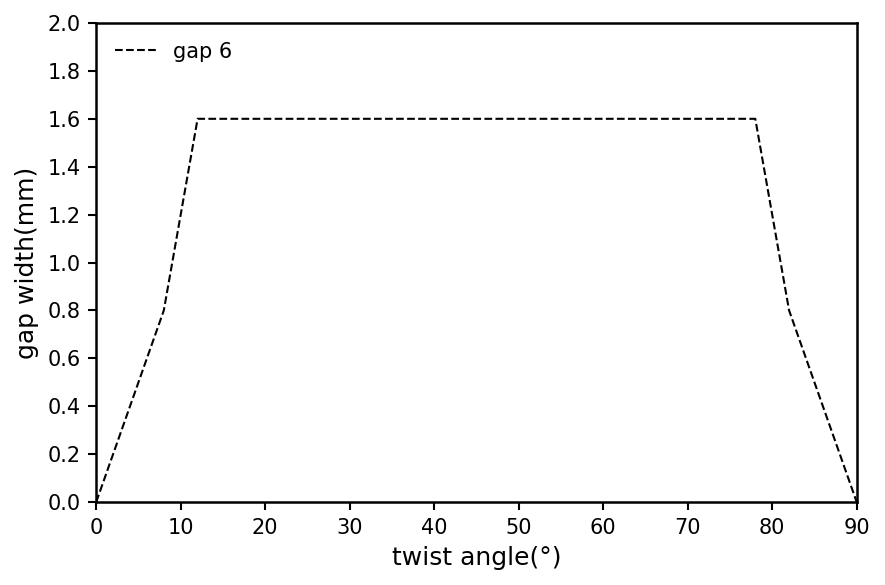

In [22]:
plot_xy([0,   8,   12,  16,  20,  30,  40,  50,  60,  78,  82,  90], 
        [0.0, 0.8, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 0.8, 0.0], 
        show = True)

In [ ]:
np.random.rand(90)

array([0.57356601, 0.07217429, 0.09548582, 0.36399613, 0.29097932,
       0.70707406, 0.97951581, 0.01629165, 0.59825989, 0.55813253])

In [9]:
import matplotlib.pyplot as plt

def plot_sample_style(
    x,
    ys,
    labels=None,
    xlabel="Length (m)",
    ylabel="Velocity (m/s)",
    subtitle="(a)  Detailed distribution",
    xlim=None, ylim=None,
    legend_loc="lower left",
    save=None, dpi=300
):
    """
    仅画图：给定 x (1D) 与 ys (list of 1D)，按示例风格出图。
    - x: 一维序列
    - ys: [y1, y2, ...]；每个 yi 与 x 等长
    - labels: 与 ys 等长的图例名列表；不传则不显示图例
    - xlim/ylim: (min, max)；不传则自动
    - save: 'fig.png' / 'fig.pdf'；不传则只返回 fig, ax
    返回: (fig, ax)
    """

    # 默认三条的颜色/标记，可自动循环
    colors  = ["tab:green", "tab:red", "tab:blue", "k", "tab:orange"]
    markers = ["o", "s", "^", "D", "v"]

    fig, ax = plt.subplots(figsize=(6, 5), dpi=100)

    # 轴外观
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(direction="out", length=4, width=1, which="major")

    # 逐条曲线
    for i, y in enumerate(ys):
        c = colors[i % len(colors)]
        m = markers[i % len(markers)]
        lab = labels[i] if labels else None
        ax.plot(
            x, y,
            linestyle="-",
            linewidth=2.0,
            color=c,
            marker=m,
            markersize=5.5,
            markerfacecolor=c,
            markeredgewidth=0.8,
            label=lab,
        )

    # 轴标签/范围
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    # 图例
    if labels:
        # ax.legend(loc=legend_loc, frameon=True, framealpha=1.0, edgecolor="black")
        ax.legend(labels, loc="lower left", frameon=False)

    # 底部副标题（示例里的 (a) …）
    if subtitle:
        fig.text(0.5, 0.01, subtitle, ha="center", va="bottom", fontsize=12, style="italic")
        fig.tight_layout(rect=[0, 0.06, 1, 1])
    else:
        fig.tight_layout()

    if save:
        fig.savefig(save, dpi=dpi, bbox_inches="tight")
    return fig, ax


(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Length (m)', ylabel='Velocity (m/s)'>)

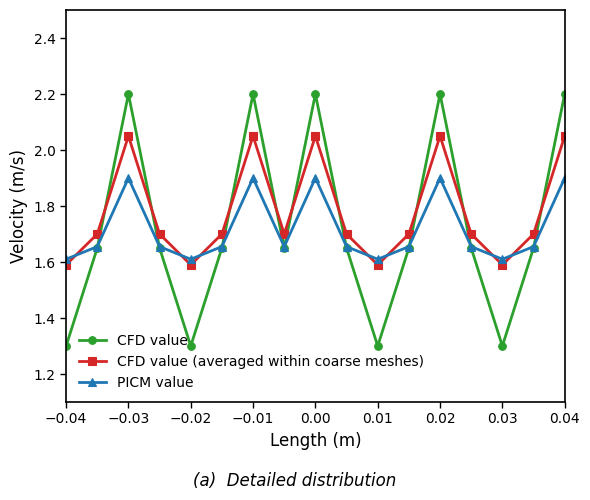

In [10]:
# 假设已有：
x = [-0.040, -0.035, -0.030, -0.025, -0.020, -0.015, -0.010, -0.005,
      0.000,  0.005,  0.010,  0.015,  0.020,  0.025,  0.030,  0.035,  0.040]

# y1 (CFD, 绿): 峰值≈2.20~2.25，谷值≈1.30
y1 = [1.300, 1.650, 2.200, 1.650, 1.300, 1.650, 2.200, 1.650,
      2.200, 1.650, 1.300, 1.650, 2.200, 1.650, 1.300, 1.650, 2.200]

# y2 (平均, 红): 峰值≈2.05，谷值≈1.60
y2 = [1.590, 1.700, 2.050, 1.700, 1.590, 1.700, 2.050, 1.700,
      2.050, 1.700, 1.590, 1.700, 2.050, 1.700, 1.590, 1.700, 2.050]

# y3 (PICM, 蓝): 峰值≈1.95，谷值≈1.61
y3 = [1.610, 1.655, 1.900, 1.655, 1.610, 1.655, 1.900, 1.655,
      1.900, 1.655, 1.610, 1.655, 1.900, 1.655, 1.610, 1.655, 1.900]

plot_sample_style(
    x,
    [y1, y2, y3],
    labels=["CFD value", "CFD value (averaged within coarse meshes)", "PICM value"],
    xlabel="Length (m)",
    ylabel="Velocity (m/s)",
    subtitle="(a)  Detailed distribution",
    xlim=(-0.04, 0.04),
    ylim=(1.1, 2.5),
    save="result.png"
)
# 若不想保存，去掉 save 参数即可；函数会返回 fig, ax 方便你进一步调整。
